# Modelagem e avaliação experimental

Regressão para prever `vote_average` a partir do dataset pré-processado em `data/processed/`. Avaliação no **conjunto de teste** com **MAE**, **RMSE** e **R²**.

**Estrutura**

1. Definição de `X` e `y`
2. Divisão treino / teste
3. Baseline (preditor constante)
4. Ridge — regressão linear regularizada
5. Random Forest
6. HistGradientBoosting
7. Tabela comparativa *(gráficos e importância de features em seguida)*


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Raiz do projeto no path (para `from src...` nos notebooks em notebooks/)
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RANDOM_STATE = 42


def rmse(y_true, y_pred):
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))


DATA_PATH = Path('../data/processed/movies_processed.csv')
df = pd.read_csv(DATA_PATH)
df.shape

(7761, 53)

In [2]:
df.head()

,title,budget,revenue,runtime,popularity,vote_count,genres,original_language,status,production_companies,...,company_United_Artists,company_StudioCanal,company_Summit_Entertainment,company_Relativity_Media,company_DreamWorks_Pictures,company_TriStar_Pictures,company_Focus_Features,company_Village_Roadshow_Pictures,company_other,year
0,Inception,160000000,825532764,148,83.952,34495,"Action, Science Fiction, Adventure",en,Released,"Legendary Pictures, Syncopy, Warner Bros. Pict...",...,0,0,0,0,0,0,0,0,1,2010
1,Interstellar,165000000,701729206,169,140.241,32571,"Adventure, Drama, Science Fiction",en,Released,"Legendary Pictures, Syncopy, Lynda Obst Produc...",...,0,0,0,0,0,0,0,0,1,2014
2,The Dark Knight,185000000,1004558444,152,130.643,30619,"Drama, Action, Crime, Thriller",en,Released,"DC Comics, Legendary Pictures, Syncopy, Isobel...",...,0,0,0,0,0,0,0,0,1,2008
3,Avatar,237000000,2923706026,162,79.932,29815,"Action, Adventure, Fantasy, Science Fiction",en,Released,"Dune Entertainment, Lightstorm Entertainment, ...",...,0,0,0,0,0,0,0,0,1,2009
4,The Avengers,220000000,1518815515,143,98.082,29166,"Science Fiction, Action, Adventure",en,Released,Marvel Studios,...,0,0,0,0,0,0,0,0,1,2012


## 1. Definição de `X` e `y`

Removem-se colunas que não entram como features (identificador, alvo, textos brutos já codificados, etc.). Ajuste `DROP_FOR_X` se o CSV mudar.


In [3]:
TARGET = 'vote_average'
DROP_FOR_X = ['title',
              'status',
              'original_language', 
              'vote_average', 
              'release_date', 
              'budget',
              'revenue',
              'popularity',
              'genres',
              'production_companies']  

X = df.drop(columns=[c for c in DROP_FOR_X if c in df.columns])
y = df[TARGET]
X.shape, y.shape

((7761, 43), (7761,))

## 2. Divisão treino / teste

Use proporção fixa e `random_state` para reprodutibilidade. O **mesmo** treino/teste deve ser usado em todos os modelos.

*Opcional:* estratificar por faixas de `vote_average` no `split`.


In [4]:
# Seção 2 — divisão treino / teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)


## 3. Baseline — preditor constante

Para cada filme do **teste**, a predição é a **média de `vote_average` no treino** (sem usar features). Referência: os modelos com features devem melhorar **MAE/RMSE** em relação a este baseline.


In [5]:
# Seção 3 — Baseline: média só do treino (não usar y_test aqui)
mean_train = y_train.mean()
# Mesma predição para todos os exemplos do teste
y_pred_baseline = np.full(shape=y_test.shape, fill_value=mean_train)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

try:
    rmse_baseline = mean_squared_error(y_test, y_pred_baseline, squared=False)
except TypeError:
    rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print('Baseline: predizer sempre a média do treino =', round(mean_train, 4))
print('--- Conjunto de teste ---')
print(f'MAE:  {mae_baseline:.4f}')
print(f'RMSE: {rmse_baseline:.4f}')
print(f'R²:   {r2_baseline:.4f}')

Baseline: predizer sempre a média do treino = 6.4894
--- Conjunto de teste ---
MAE:  0.6718
RMSE: 0.8440
R²:   -0.0004


## 4. Ridge — regressão linear regularizada

- **`StandardScaler`**: padroniza features no **treino** e aplica a mesma transformação no **teste**.
- **`Ridge`**: regressão linear com penalidade L2; parâmetro `alpha` (aqui `1.0`).
- **`Pipeline`**: o escalonamento é ajustado só com `X_train`; o teste não entra no `fit` do `scaler`.

*Opcional:* ajustar `alpha` com `GridSearchCV` no treino.


In [6]:
# Seção 4 — Ridge (Pipeline: StandardScaler + Ridge)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from src.utils import error_metrics

ridge_pipe = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]
)

ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)

error_metrics(y_test, y_pred_ridge)

MAE:  0.4817
RMSE: 0.6374
R²:   0.4295


(0.4816533787482536, np.float64(0.6374096044924223), 0.4294851142998999)

## 5. Random Forest Regressor

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

error_metrics(y_test, y_pred_rf)

MAE:  0.4207
RMSE: 0.5695
R²:   0.5446


(0.4207480231809403, np.float64(0.5694968007874563), 0.5445797351234649)

## 6. HistGradientBoostingRegressor

In [8]:
from sklearn.ensemble import HistGradientBoostingRegressor
from src.utils import error_metrics

hgb = HistGradientBoostingRegressor(
    max_iter=200,
    random_state=RANDOM_STATE
)

hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)

error_metrics(y_test, y_pred_hgb)



MAE:  0.3994
RMSE: 0.5502
R²:   0.5749


(0.39942898847587216, np.float64(0.5502007004381821), 0.5749186492099682)

## 7. Tabela comparativa

In [9]:
from IPython.display import display
from src.utils import regression_metrics

rows = [
    {'modelo': 'Baseline (média treino)', **regression_metrics(y_test, y_pred_baseline)},
    {'modelo': 'Ridge (α=1.0)', **regression_metrics(y_test, y_pred_ridge)},
    {'modelo': 'Random Forest (n_estimators=200)', **regression_metrics(y_test, y_pred_rf)},
    {'modelo': 'HistGradientBoosting (max_iter=200)', **regression_metrics(y_test, y_pred_hgb)},
]

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.sort_values('MAE').reset_index(drop=True)
comparison_df['MAE'] = comparison_df['MAE'].round(4)
comparison_df['RMSE'] = comparison_df['RMSE'].round(4)
comparison_df['R2'] = comparison_df['R2'].round(4)

display(comparison_df)

,modelo,MAE,RMSE,R2
0,HistGradientBoosting (max_iter=200),0.3994,0.5502,0.5749
1,Random Forest (n_estimators=200),0.4207,0.5695,0.5446
2,Ridge (α=1.0),0.4817,0.6374,0.4295
3,Baseline (média treino),0.6718,0.8440,-0.0004


## 8. Gráficos do melhor modelo (conjunto de teste)
**Esquerda:** nota real × nota predita (pontos sobre a diagonal vermelha = predição perfeita).  
**Direita:** resíduos (real − predito) × predito, para ver viés e dispersão.

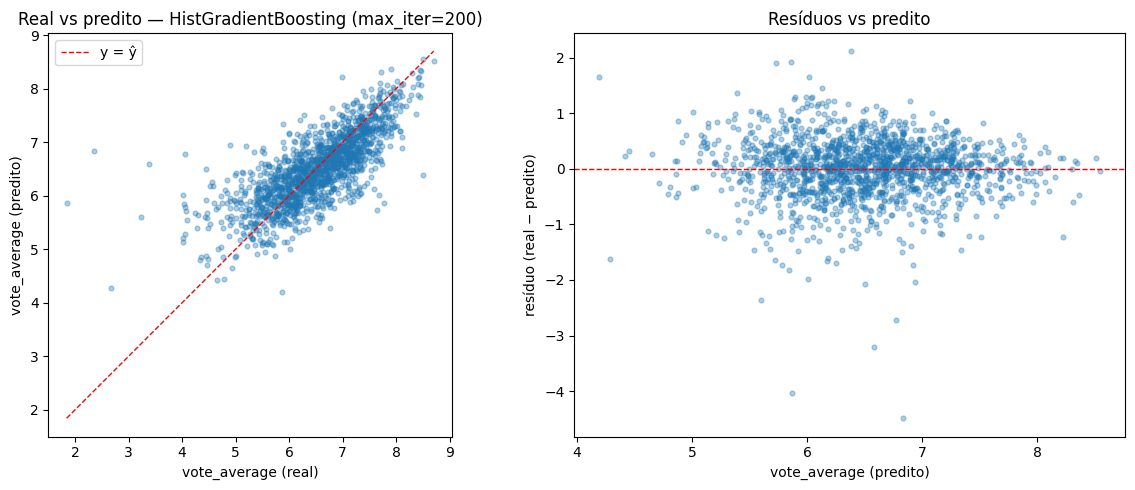

In [10]:
import matplotlib.pyplot as plt

y_pred_plot = y_pred_hgb  # melhor modelo no seu experimento
nome_modelo = 'HistGradientBoosting (max_iter=200)'

residuals = y_test - y_pred_plot

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred_plot, alpha=0.35, s=12)
lo, hi = float(y_test.min()), float(y_test.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1, label='y = ŷ')
axes[0].set_xlabel('vote_average (real)')
axes[0].set_ylabel('vote_average (predito)')
axes[0].set_title(f'Real vs predito — {nome_modelo}')
axes[0].legend()
axes[0].set_aspect('equal', adjustable='box')

axes[1].scatter(y_pred_plot, residuals, alpha=0.35, s=12)
axes[1].axhline(0, color='r', linestyle='--', lw=1)
axes[1].set_xlabel('vote_average (predito)')
axes[1].set_ylabel('resíduo (real − predito)')
axes[1].set_title('Resíduos vs predito')

plt.tight_layout()
plt.show()

### 9.1 Histograma e Q-Q dos resíduos

O histograma mostra a forma da distribuição dos erros; o gráfico Q-Q ajuda a avaliar se os resíduos são aproximadamente normais (pontos próximos da reta).

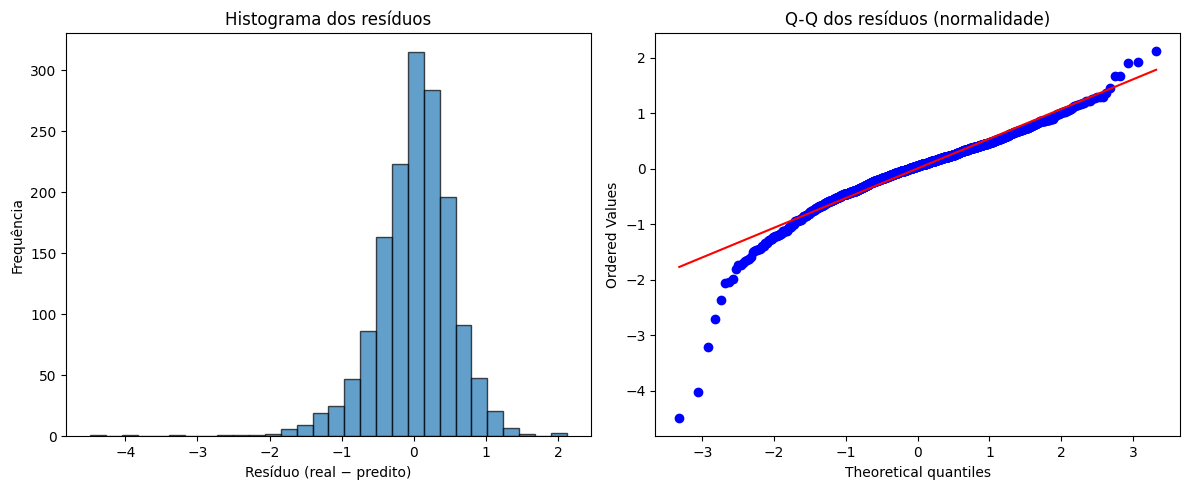

In [11]:
from scipy import stats

residuals = y_test - y_pred_plot

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Resíduo (real − predito)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Histograma dos resíduos')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q dos resíduos (normalidade)')

plt.tight_layout()
plt.show()

## 10. Importância das features (permutation importance)

Mede quanto o desempenho no **teste** piora quando cada coluna é embaralhada aleatoriamente (maior queda = feature mais relevante para o HGB treinado).

In [12]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    hgb, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
imp_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

display(imp_df.head(25))

top_k = 15
top_feats = imp_df['feature'].head(top_k).tolist()
X_train_top = X_train[top_feats]
X_test_top = X_test[top_feats]

hgb_top = HistGradientBoostingRegressor(max_iter=200, random_state=RANDOM_STATE)
hgb_top.fit(X_train_top, y_train)
y_pred_top = hgb_top.predict(X_test_top)

print('HGB só com top-%d features (permutation):' % top_k)
error_metrics(y_test, y_pred_top)

,feature,importance_mean,importance_std
1,vote_count,0.919599,0.036151
3,log_budget,0.262575,0.016592
0,runtime,0.173604,0.013603
2,release_year,0.162803,0.012202
4,log_revenue,0.073135,0.005653
18,genre_Animation,0.044077,0.005006
6,genre_Drama,0.043345,0.005441
13,genre_Horror,0.035708,0.004913
5,log_popularity,0.018165,0.007007
7,genre_Comedy,0.016655,0.003232


HGB só com top-15 features (permutation):
MAE:  0.4065
RMSE: 0.5551
R²:   0.5673


(0.4064746920994938, np.float64(0.5551227933692336), 0.5672790779839512)

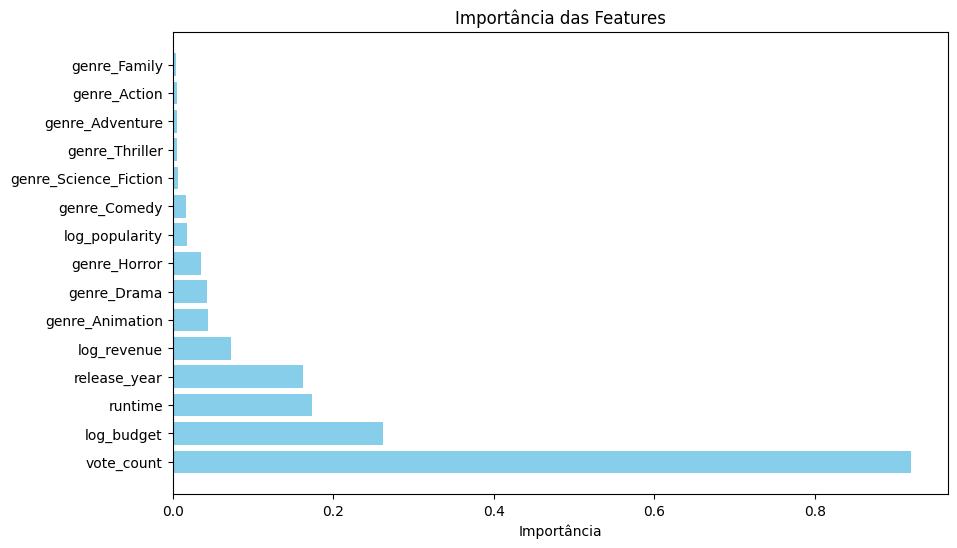

In [16]:
#Gráfico de barras com as 15 features mais importantes
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_feats, imp_df['importance_mean'].head(15), color='skyblue')
plt.xlabel('Importância')
plt.title('Importância das Features')
plt.show()

## 11. Validação cruzada (HGB só no treino)

`cross_validate` com 20 folds no **conjunto de treino** para ver variabilidade das métricas (sem usar o teste).

In [15]:
from sklearn.model_selection import cross_validate

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2',
}
cv_res = cross_validate(
    HistGradientBoostingRegressor(max_iter=200, random_state=RANDOM_STATE),
    X_train,
    y_train,
    cv=20,
    scoring=scoring,
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    'métrica': ['MAE', 'RMSE', 'R²'],
    'média': [
        -cv_res['test_mae'].mean(),
        -cv_res['test_rmse'].mean(),
        cv_res['test_r2'].mean(),
    ],
    'std': [
        cv_res['test_mae'].std(),
        cv_res['test_rmse'].std(),
        cv_res['test_r2'].std(),
    ],
})
display(cv_summary)

,métrica,média,std
0,MAE,0.390131,0.018677
1,RMSE,0.521081,0.034069
2,R²,0.586577,0.038444


## 12. Exemplos no conjunto de teste (com títulos)

Os índices de `y_test` / `X_test` coincidem com as linhas do `DataFrame` original; usamos `title` para inspecionar predições filme a filme.

In [17]:
comparacao = pd.DataFrame({
    'title': df.loc[y_test.index, 'title'].values,
    'vote_real': y_test.values,
    'vote_predito': y_pred_plot,
    'erro_abs': (y_test - y_pred_plot).abs().values,
})

print('Amostra (20 menores erros absolutos no teste):')
display(comparacao.sort_values('erro_abs').head(20))

print('\nTop 10 por maior nota real no teste:')
display(comparacao.sort_values('vote_real', ascending=False).head(10))

print('\n Primeiros 50 filmes do conjunto de teste:')
display(comparacao.head(50))

Amostra (20 menores erros absolutos no teste):


,title,vote_real,vote_predito,erro_abs
1427,"Tomorrow, When the War Began",6.166,6.165798,0.000202
495,Braven,6.204,6.203228,0.000772
734,The Silence of the Lambs,8.300,8.298239,0.001761
1215,The Italian Job,6.763,6.760900,0.002100
794,The Bubble,6.702,6.704751,0.002751
946,City Heat,5.500,5.496296,0.003704
1058,Insomnia,6.900,6.895871,0.004129
657,Legends of the Fall,7.388,7.382263,0.005737
766,May God Save Us,6.714,6.720178,0.006178
570,Alaska,5.796,5.802436,0.006436



Top 10 por maior nota real no teste:


,title,vote_real,vote_predito,erro_abs
1459,The Shawshank Redemption,8.702,8.514854,0.187146
760,The Green Mile,8.507,8.547479,0.040479
269,Evanescence - Synthesis Live,8.500,6.381438,2.118562
1359,"The Good, the Bad and the Ugly",8.473,8.071550,0.401450
1499,GoodFellas,8.464,8.328531,0.135469
938,Grave of the Fireflies,8.455,8.344792,0.110208
878,Cinema Paradiso,8.453,7.840767,0.612233
1312,One Flew Over the Cuckoo's Nest,8.420,8.226563,0.193437
707,Howl's Moving Castle,8.402,8.094412,0.307588
553,The Lord of the Rings: The Fellowship of the Ring,8.402,8.197821,0.204179



 Primeiros 50 filmes do conjunto de teste:


,title,vote_real,vote_predito,erro_abs
0,Remember Me,7.102,7.390620,0.288620
1,The Rescuers Down Under,6.616,6.461102,0.154898
2,Kramer vs. Kramer,7.555,7.216428,0.338572
3,King Kong,7.610,7.492597,0.117403
4,The Dressmaker,6.992,6.923613,0.068387
5,Heaven's Gate,6.740,6.764574,0.024574
6,Unfinished Business,5.445,5.358725,0.086275
7,Sliver,5.446,6.380640,0.934640
8,Babysitting 2,6.300,6.267501,0.032499
9,The Man with the Golden Arm,7.159,6.956043,0.202957
